In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 78.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e9564d85a5367bb570a98402abed0968810393b6bab652ab7f0afc10d24696b5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## Grover's Algorithm: Conceptual and Code Explanation

Grover's algorithm is a quantum algorithm that offers a quadratic speedup over classical algorithms for searching an unsorted database. Given a function `f` that evaluates to 1 for a single 'marked' item `w` and 0 for all other items, Grover's algorithm aims to find `w`.

### The Oracle ($U_f$)

The core of the algorithm is a unitary operator called the 'oracle,' denoted as $U_f$. This oracle marks the target state `w` by applying a phase flip. Specifically:

*   $U_f |x\rangle = -|x\rangle$ if $x = w$ (the target state)
*   $U_f |x\rangle = |x\rangle$ if $x \neq w$ (any other state)

In the provided code, the `U` matrix represents this oracle. For a 3-qubit system, an 8x8 matrix is used. The target state `|000>` (which corresponds to the first element in the computational basis, index 0) is marked by having its corresponding diagonal element as -1, while all other diagonal elements are 1.

```python
U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0], # -1 for |000>
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])
```

To change the search target, you would modify this `U` matrix. For example, if you wanted to search for `|010>` (which is index 2 in binary), you would change `U[2][2]` to `-1` and `U[0][0]` to `1`.

### The Grover Diffusion Operator ($U_s$)

After applying the oracle, the algorithm uses a diffusion operator, $U_s$, also known as the 'Grover Diffusion Operator' or 'Amplitude Amplification' operator. This operator inverts the amplitudes about the average amplitude, effectively boosting the amplitude of the marked state and decreasing the amplitudes of the unmarked states. For an N-dimensional search space, $U_s = 2|s\rangle\langle s| - I$, where $|s\rangle$ is the uniform superposition state (all states have equal amplitude) and $I$ is the identity matrix.

In the code, `G_matrix` defines this operator for a 3-qubit system (N=8). Each element is scaled by `1/4.0` (since `2/N = 2/8 = 1/4`).

```python
G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1], # ...and so on
    # ... (rest of the matrix)
]))

G = Operator(G_matrix)
```

### The Algorithm Steps

1.  **Initialization**: All qubits are put into a uniform superposition state. This is achieved by applying a Hadamard gate (`h`) to each qubit. In the code:

```python
grover.h(0)
grover.h(1)
grover.h(2)
```

2.  **Iteration**: The oracle $U_f$ and the diffusion operator $U_s$ are applied a certain number of times. The optimal number of iterations for an N-item database with one marked item is approximately $\frac{\pi}{4}\sqrt{N}$. For 3 qubits, $N=2^3=8$, so the optimal number of iterations is $\frac{\pi}{4}\sqrt{8} \approx \frac{3.14}{4} \times 2.828 \approx 2.22$. The code uses 2 iterations, which is close to optimal.

```python
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
```

3.  **Measurement**: After the iterations, measuring the qubits will yield the marked state `w` with a high probability.

```python
grover.measure_all()
```

### Simulation and Visualization

The code then simulates the quantum circuit using `BasicSimulator` and visualizes the measurement results as a histogram, showing the probability distribution of outcomes.

```python
backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)
```

This setup effectively demonstrates Grover's algorithm for finding the state `|000>` within an 8-state space using Qiskit.

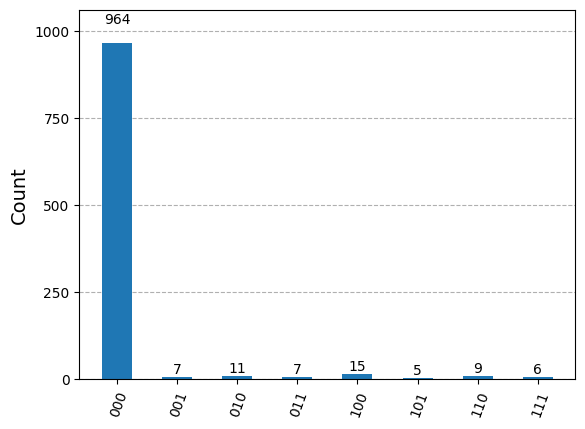

In [2]:
# Grover's algorithm
# Given a function f : {0,1}^n -> {0,1} such that for some input vector w,
# f(w) = 1 and for all x != w, f(x) = 0.
# The problem is to find w.

# Here we work with 3 qubits

# First we need a definition of f.

# Let's say f(0,0,0) = 1
# Try changing this to represent different search targets (you will need to change the definition of U, below)

# Then we need to define a unitary operator U on 3 qubits, such that
# U|x> = -|x> if f(x) = 1
# U|x> =  |x> if f(x) = 0

U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# Now construct the Grover diffusion operator

G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1],
    [1,-3, 1, 1, 1, 1, 1, 1],
    [1, 1,-3, 1, 1, 1, 1, 1],
    [1, 1, 1,-3, 1, 1, 1, 1],
    [1, 1, 1, 1,-3, 1, 1, 1],
    [1, 1, 1, 1, 1,-3, 1, 1],
    [1, 1, 1, 1, 1, 1,-3, 1],
    [1, 1, 1, 1, 1, 1, 1,-3]
]))

G = Operator(G_matrix)

# Build a circuit with the correct number of iterations hard-coded, in this case 2

grover = QuantumCircuit(3)

# To get the initial state, apply H to every qubit

grover.h(0)
grover.h(1)
grover.h(2)

# Repeatedly apply U then G

grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])

# What if we do too many iterations?

#grover.append(U,[0,1,2])
#grover.append(G,[0,1,2])

# Measure all the qubits - to do that, we don't need to introduce classical bits

grover.measure_all()

# Simulate and plot results

backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)